
Logistic Regression Results:
Accuracy: 0.9700
AUC: 0.9902
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        91
           1       0.88      0.78      0.82         9

    accuracy                           0.97       100
   macro avg       0.93      0.88      0.90       100
weighted avg       0.97      0.97      0.97       100


Random Forest Results:
Accuracy: 0.9800
AUC: 0.9976
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        91
           1       0.89      0.89      0.89         9

    accuracy                           0.98       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.98      0.98      0.98       100



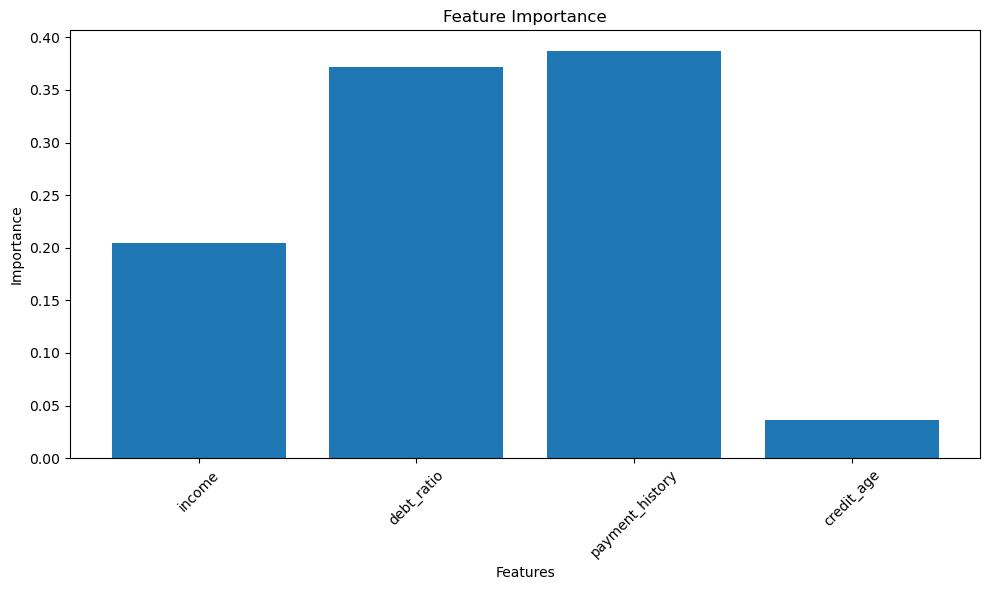

In [7]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
n = 500
df = pd.DataFrame({
    'income': np.random.normal(50000, 15000, n),
    'debt_ratio': np.random.uniform(0, 1, n),
    'payment_history': np.random.randint(0, 100, n),
    'credit_age': np.random.randint(0, 20, n)
})
df['creditworthy'] = (df['income'] > 45000) & (df['debt_ratio'] < 0.4) & (df['payment_history'] > 70)
df['creditworthy'] = df['creditworthy'].astype(int)

# Split data
X = df.drop('creditworthy', axis=1)
y = df['creditworthy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
plt.figure(figsize=(10, 6))
plt.bar(features, importance)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()